# ARC_ATLAS v4 Slice-Block Training

This notebook runs the 2.5D slice-block trainer in `src/training_v2_slice_blocks.py`.

- One Keras training step is one entire brain.
- Each brain is converted to overlapping 3-slice blocks: `(num_slices, full_x, full_y, 3)`.
- The network predicts the center slice for each block.
- Validation stitches slice probabilities back into a full 3D probability map and also saves thresholded segmentations.
- `FIT_VERBOSE=2` prints one line per epoch in the notebook output.


In [1]:
from pathlib import Path
import sys
import time

candidates = [
    Path.cwd(),
    Path.cwd() / "ARC_ATLAS_Combined" / "ARC_ATLAS_Train_v4",
    Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4"),
]
PROJECT_ROOT = next(
    (p for p in candidates if (p / "src" / "training_v2_slice_blocks.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate ARC_ATLAS_Train_v4/src/training_v2_slice_blocks.py")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import training_v2_slice_blocks as seg

TRAIN_DIR = PROJECT_ROOT / "data" / "splits" / "90_10_random" / "train"
RUN_DIR = PROJECT_ROOT / "runs" / f"{time.strftime('%Y%m%d_%H%M%S')}_slice_blocks"

cfg = seg.SliceBlockTrainingConfig(
    DATA_DIR=TRAIN_DIR,
    IMAGES_DIR=TRAIN_DIR / "t1",
    MASKS_DIR=TRAIN_DIR / "masks",
    MANIFEST_PATH=TRAIN_DIR / "manifest.csv",
    MODEL_DIR=RUN_DIR / "models",
    CALLBACKS_DIR=RUN_DIR / "callbacks",
    TARGET_SHAPE=(192, 224, 192),
    RESAMPLE_TO_TARGET=False,
    SLICE_AXIS=2,
    BLOCK_DEPTH=3,
    SLICE_STRIDE=1,
    TOTAL_EPOCHS=120,
    INITIAL_LR=2e-4,
    BASE_FILTERS=8,
    UNET_DEPTH=4,
    DECISION_THRESHOLD=0.35,
    WHOLE_BRAIN_VAL_EVERY_N_EPOCHS=1,
    WHOLE_BRAIN_VAL_MAX_CASES=None,
    SAVE_VAL_PREDICTIONS=True,
    NUM_VAL_PREDICTIONS=3,
    FIT_VERBOSE=2,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Training data: {TRAIN_DIR}")
print(f"Run dir: {RUN_DIR}")
print(f"Input per brain: (num_slices, {cfg.input_shape[0]}, {cfg.input_shape[1]}, {cfg.input_shape[2]})")
print(f"Best checkpoint: {cfg.checkpoint_path}")
print(f"Epoch log CSV: {cfg.CALLBACKS_DIR / 'training_log.csv'}")
print(f"Whole-brain validation summary: {cfg.CALLBACKS_DIR / 'whole_val_summary.jsonl'}")
print(f"Probability/segmentation outputs: {cfg.CALLBACKS_DIR / 'predictions'}")


2026-04-20 12:06:54.717607: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Project root: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4
Training data: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train
Run dir: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260420_120656_slice_blocks
Input per brain: (num_slices, 192, 224, 3)
Best checkpoint: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260420_120656_slice_blocks/callbacks/best_slice_block.weights.h5
Epoch log CSV: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260420_120656_slice_blocks/callbacks/training_log.csv
Whole-brain validation summary: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260420_120656_slice_blocks/callbacks/whole_val_summary.jsonl
Probability/segmentation outputs: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260420_120656_slice_blocks/callbacks/predictions


In [2]:
# Sanity check the real full-geometry input before launching training.
cases = seg.load_cases(cfg)
image, mask, _ = seg.load_case_arrays(cases[0], cfg)
x, y = seg.make_slice_blocks(image, mask, cfg)
model = seg.build_slice_block_model(cfg)

print(f"Cases: {len(cases)}")
print(f"Prepared brain: image={image.shape}, mask={mask.shape}")
print(f"One-brain batch: x={x.shape}, y={y.shape}")
print(f"Lesion voxels in sanity case: {int(y.sum())}")
print(f"Model params: {model.count_params():,}")

del model
seg.tf.keras.backend.clear_session()


2026-04-20 12:06:56,441 - SliceBlockTrainer - INFO - Using manifest: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train/manifest.csv
2026-04-20 12:06:56,461 - SliceBlockTrainer - INFO - Loaded 866 cases from manifest
I0000 00:00:1776708417.398800 2638561 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22148 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1776708417.400228 2638561 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22122 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:61:00.0, compute capability: 8.9


Cases: 866
Prepared brain: image=(192, 224, 192), mask=(192, 224, 192)
One-brain batch: x=(192, 192, 224, 3), y=(192, 192, 224, 1)
Lesion voxels in sanity case: 149459
Model params: 493,345


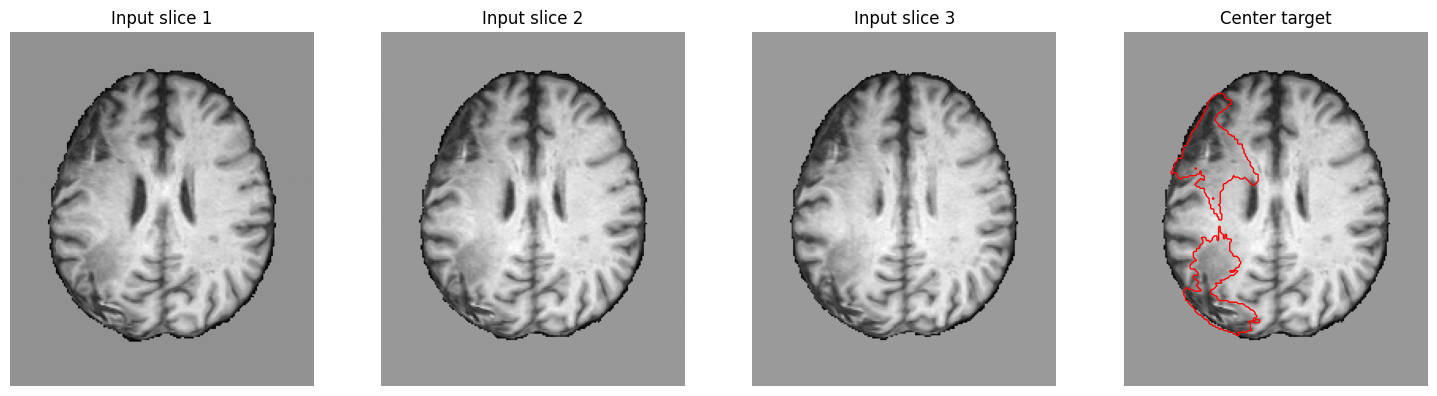

In [3]:
# Optional visual sanity check for one 3-slice input block and center-slice target.
import matplotlib.pyplot as plt
import numpy as np

center_idx = int(np.argmax(y.reshape(y.shape[0], -1).sum(axis=1)))
block = x[center_idx]
target = y[center_idx, ..., 0]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for channel, ax in enumerate(axes[:3]):
    ax.imshow(block[..., channel].T, cmap="gray", origin="lower")
    ax.set_title(f"Input slice {channel + 1}")
    ax.axis("off")
axes[3].imshow(block[..., 1].T, cmap="gray", origin="lower")
if target.any():
    axes[3].contour(target.T, levels=[0.5], colors=["red"], linewidths=1.0)
axes[3].set_title("Center target")
axes[3].axis("off")
plt.tight_layout()


In [ ]:
# Launch training. FIT_VERBOSE=2 prints one line per epoch here.
# Whole-brain validation runs each epoch and writes CSV/JSONL diagnostics plus best-epoch NIfTI outputs.
history = seg.train_slice_block_model(cfg)


2026-04-20 12:06:58,594 - SliceBlockTrainer - WARNING - Could not set memory growth on PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'): Physical devices cannot be modified after being initialized
2026-04-20 12:06:58,594 - SliceBlockTrainer - WARNING - Could not set memory growth on PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'): Physical devices cannot be modified after being initialized
2026-04-20 12:06:58,595 - SliceBlockTrainer - INFO - Using manifest: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/data/splits/90_10_random/train/manifest.csv
2026-04-20 12:06:58,615 - SliceBlockTrainer - INFO - Loaded 866 cases from manifest
2026-04-20 12:08:58,451 - SliceBlockTrainer - INFO - Split cases: train=737 val=129
2026-04-20 12:08:58,656 - SliceBlockTrainer - INFO - Model built: SliceBlock2p5D_UNet params=493345 input=(192, 224, 3)
2026-04-20 12:08:58,657 - SliceBlockTrainer - INFO - Slice-block design: one brain per step, block_depth=

Epoch 1/120


2026-04-20 12:09:05.263094: I external/local_xla/xla/service/service.cc:163] XLA service 0x749fd8002ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-20 12:09:05.263123: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-20 12:09:05.263130: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-20 12:09:05.582830: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-20 12:09:07.130440: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91001
I0000 00:00:1776708564.628744 2638715 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-04-20 12:22:48,926 - SliceBlockTrain


Epoch 1: val_whole_dice_hard_best_thr_score improved from None to 0.07925, saving model to /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260420_120656_slice_blocks/callbacks/best_slice_block.weights.h5
737/737 - 975s - 1s/step - dice_coefficient: 0.0162 - foreground_fraction: 0.1498 - hard_dice_metric: 0.2566 - loss: 0.8234 - val_dice_coefficient: 0.0231 - val_foreground_fraction: 0.0856 - val_hard_dice_metric: 0.3696 - val_loss: 0.7424 - val_whole_dice_soft_macro: 0.0276 - val_whole_dice_hard: 0.0554 - val_whole_dice_hard_best_thr: 0.5000 - val_whole_dice_hard_best_thr_score: 0.0792
Epoch 2/120


2026-04-20 12:38:36,579 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 16/129
2026-04-20 12:38:56,356 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 32/129
2026-04-20 12:39:16,126 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 48/129
2026-04-20 12:39:35,872 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 64/129
2026-04-20 12:39:55,602 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 80/129
2026-04-20 12:40:15,355 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 96/129
2026-04-20 12:40:35,128 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 112/129
2026-04-20 12:40:54,914 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 128/129
2026-04-20 12:40:56,156 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 129/129
2026-04-20 12:40:56,160 - SliceBlockTrainer - INFO - Whole-brain slice-block val @epoch 1: soft=0.04151 hard@0.35=0

...


Epoch 16: val_whole_dice_hard_best_thr_score did not improve from 0.20218
737/737 - 941s - 1s/step - dice_coefficient: 0.0420 - foreground_fraction: 0.0260 - hard_dice_metric: 0.5922 - loss: 0.6072 - val_dice_coefficient: 0.0530 - val_foreground_fraction: 0.0233 - val_hard_dice_metric: 0.5660 - val_loss: 0.5638 - val_whole_dice_soft_macro: 0.1094 - val_whole_dice_hard: 0.1334 - val_whole_dice_hard_best_thr: 0.5000 - val_whole_dice_hard_best_thr_score: 0.1606
Epoch 17/120


2026-04-20 16:33:52,104 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 16/129
2026-04-20 16:34:11,792 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 32/129
2026-04-20 16:34:31,531 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 48/129
2026-04-20 16:34:51,280 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 64/129
2026-04-20 16:35:11,074 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 80/129
2026-04-20 16:35:30,912 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 96/129
2026-04-20 16:35:50,934 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 112/129
2026-04-20 16:36:10,954 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 128/129
2026-04-20 16:36:12,189 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 129/129
2026-04-20 16:36:12,193 - SliceBlockTrainer - INFO - Whole-brain slice-block val @epoch 16: soft=0.10745 hard@0.35=


Epoch 17: val_whole_dice_hard_best_thr_score did not improve from 0.20218
737/737 - 944s - 1s/step - dice_coefficient: 0.0443 - foreground_fraction: 0.0253 - hard_dice_metric: 0.5948 - loss: 0.6021 - val_dice_coefficient: 0.0540 - val_foreground_fraction: 0.0161 - val_hard_dice_metric: 0.6681 - val_loss: 0.5656 - val_whole_dice_soft_macro: 0.1075 - val_whole_dice_hard: 0.1565 - val_whole_dice_hard_best_thr: 0.5000 - val_whole_dice_hard_best_thr_score: 0.1964
Epoch 18/120


2026-04-20 16:49:34,678 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 16/129
2026-04-20 16:49:54,385 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 32/129
2026-04-20 16:50:14,234 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 48/129
2026-04-20 16:50:34,080 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 64/129
2026-04-20 16:50:53,906 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 80/129
2026-04-20 16:51:13,705 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 96/129
2026-04-20 16:51:33,508 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 112/129
2026-04-20 16:51:53,331 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 128/129
2026-04-20 16:51:54,549 - SliceBlockTrainer - INFO - Whole-brain slice-block val progress: 129/129
2026-04-20 16:51:54,553 - SliceBlockTrainer - INFO - Whole-brain slice-block val @epoch 17: soft=0.12418 hard@0.35=


Epoch 18: val_whole_dice_hard_best_thr_score improved from 0.20218 to 0.21126, saving model to /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v4/runs/20260420_120656_slice_blocks/callbacks/best_slice_block.weights.h5
737/737 - 948s - 1s/step - dice_coefficient: 0.0430 - foreground_fraction: 0.0256 - hard_dice_metric: 0.5975 - loss: 0.6040 - val_dice_coefficient: 0.0591 - val_foreground_fraction: 0.0137 - val_hard_dice_metric: 0.6530 - val_loss: 0.5537 - val_whole_dice_soft_macro: 0.1242 - val_whole_dice_hard: 0.1780 - val_whole_dice_hard_best_thr: 0.5000 - val_whole_dice_hard_best_thr_score: 0.2113
Epoch 19/120


In [ ]:
# Review epoch-level logs after or during a stopped run.
import json
import pandas as pd

train_log = cfg.CALLBACKS_DIR / "training_log.csv"
whole_val_log = cfg.CALLBACKS_DIR / "whole_val_summary.jsonl"

if train_log.exists():
    display(pd.read_csv(train_log).tail(10))
else:
    print(f"Training log not found yet: {train_log}")

if whole_val_log.exists():
    rows = [json.loads(line) for line in whole_val_log.read_text().splitlines() if line.strip()]
    display(pd.DataFrame(rows).tail(10))
else:
    print(f"Whole-brain validation log not found yet: {whole_val_log}")


In [ ]:
# Optional: export probability map and threshold segmentation for one case from trained weights.
weights = cfg.checkpoint_path if cfg.checkpoint_path.exists() else cfg.latest_path
if not weights.exists():
    raise FileNotFoundError(f"No trained weights found yet: {weights}")

inference_model = seg.build_slice_block_inference_model(cfg, weights_path=weights)
case = seg.load_cases(cfg)[0]
prob, mask, ref_img = seg.predict_case_probability_map(inference_model, case, cfg)
out_dir = cfg.CALLBACKS_DIR / "manual_prediction"
seg.save_case_outputs(out_dir, case, prob, cfg.DECISION_THRESHOLD, ref_img)

print(f"Saved probability map and threshold segmentation to: {out_dir}")
print(f"Probability range: min={float(prob.min()):.6f}, max={float(prob.max()):.6f}")
print(f"Threshold voxels @ {cfg.DECISION_THRESHOLD:.2f}: {int((prob >= cfg.DECISION_THRESHOLD).sum())}")
